<a href="https://colab.research.google.com/github/replysantosh-lang/ECARComputerVissionGenAI/blob/main/cv_pin_inspection_assignment_arpan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TEST
# Module name : Computer Vision

# **Project Summary: Automated Pin Inspection using YOLOv8**

## Overview
This project focuses on building an **automated object detection system** for industrial pin inspection using deep learning. The goal is to detect different types of pin conditions (good and defective) and automatically decide whether a pin box should be accepted or rejected.

The system is built using **Ultralytics YOLOv8**, a state-of-the-art object detection framework, and leverages **transfer learning** on a pre-trained model to improve training efficiency and accuracy.

## Dataset Preparation
The dataset was manually annotated using **CVAT (Computer Vision Annotation Tool)**. Each object in the images was labeled with bounding boxes and exported in **YOLO format**.

The dataset includes multiple classes:
- `1_pin` (good pins)
- `2_pin`, `3_pin` (structural issues)
- `missing_pin`
- `front_bend`
- `broken`
- `wrong_color`
- `contamination`
- `missing_separator`

The dataset was split into:
- 90% training data
- 10% testing data (ensuring at least 7 defective images)

## Model Training
Multiple YOLOv8 models were trained and experimented with:
- YOLOv8s (baseline model)
- YOLOv8n (lightweight model)
- YOLOv8n with data augmentation
- YOLOv8n with hyperparameter tuning

Training was performed using:
- Transfer learning from pretrained YOLOv8 weights
- Data augmentation techniques (rotation, scaling, flipping, HSV adjustments)
- Hyperparameter tuning (learning rate, image size, batch size)

## Model Evaluation
The models were evaluated using standard object detection metrics:
- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95

Additional evaluation tools included:
- Precision–Recall curves
- F1-score curves
- Confusion matrix analysis

The best-performing model was selected based on **overall mAP and balanced precision-recall performance**.

## Box Accept/Reject System
A rule-based decision system was implemented on top of the YOLO predictions:

### Accept Criteria
- Exactly 15 good pins (`1_pin`)
- No defective objects detected

### Reject Criteria
- Any defect detected (all classes except `1_pin`)
- Missing separator
- Incorrect or additional pin detections

This ensures real-world applicability in automated quality inspection systems.

## Outcome
The project successfully demonstrates how deep learning can be applied to industrial inspection tasks. The final system is capable of:
- Detecting multiple defect types
- Evaluating object-level quality
- Making automatic accept/reject decisions

## Technologies Used
- Python
- Ultralytics YOLOv8
- OpenCV
- CVAT (annotation tool)
- Matplotlib & Pandas
- Google Colab

# **1.Dataset Preparation**

# Dataset Preparation (4 Marks)

## 1. Dataset Annotation

- The dataset was manually annotated using **CVAT**.
- Bounding boxes were drawn around all objects belonging to the required defect classes.
- Every object in each bin image was carefully labeled according to the assignment requirements.

## 2. Export Dataset

- After completing the annotation process, the dataset was exported in **YOLO Detection** format.

**YOLO Annotation Format**

```text
<class_id> <x_center> <y_center> <width> <height>
```

where:

- `class_id` represents the object class.
- `x_center` and `y_center` are the normalized center coordinates.
- `width` and `height` are the normalized bounding box dimensions.
- All values are normalized between **0** and **1**.

## 3. Dataset Verification

The exported dataset was verified to ensure:

- Every image has a corresponding annotation file.
- Every annotation file has a corresponding image.
- No missing images or labels exist.
- The number of images and labels in each dataset split is correct.

## 4. Dataset Split

The dataset was divided into:

- **90%** for model development (training/validation)
- **10%** for testing

The split distribution was verified by counting the number of images in each folder.

## 5. Test Set Validation

The test dataset was further verified to ensure it satisfies the assignment requirement:

- The test set contains **at least seven bad images**.
- The split was checked programmatically before training.

## 6. Annotation Visualization

Random samples from the dataset were visualized by drawing the annotated bounding boxes on the original images.

This visual inspection confirmed that:

- Bounding boxes correctly surround the target objects.
- Class labels are correctly assigned.
- Annotation quality is suitable for training the object detection model.

# **Annotation (CVAT)**

# Dataset Annotation

The images were manually annotated using **CVAT**. Bounding boxes were drawn around each object belonging to the required defect classes.

After annotation, the dataset was exported in **YOLO Detection** format.

### YOLO Annotation Format

```text
<class_id> <x_center> <y_center> <width> <height>
```

where:

- `class_id` represents the object class.
- `x_center` and `y_center` are the normalized center coordinates.
- `width` and `height` are the normalized bounding box dimensions.
- All coordinates are normalized between **0** and **1**.

> **Note:** Annotation is performed manually in **CVAT**; therefore, no Python code is required for this step.

# **Required Imports**

In [1]:
# Install the Ultralytics package, which provides the YOLOv8
# framework for object detection. This library includes
# pre-trained models, training utilities, inference functions,
# and evaluation tools required to build and assess the object
# detection model.
!pip install ultralytics

import os
import random
from glob import glob

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Image
from ultralytics import YOLO  # Core YOLO model library for training, validation, and inference

# Google Colab drive module to mount Google Drive dataset
from google.colab import drive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **Mount Google Drive**

In [2]:
# Mount Google Drive to access the dataset stored in Google Drive.
# Once mounted, all files and folders inside Google Drive become
# accessible from the Colab environment through the path:
#
#     /content/drive
#
# This allows the notebook to directly read the dataset, save
# trained models, and store results without manually uploading
# files each time the notebook is executed.


drive.mount('/content/drive')

Mounted at /content/drive


# **Dataset Path**

In [3]:


# Specify the location of the dataset stored in Google Drive.
# This directory contains the dataset folders such as
# train, valid, and test, along with their corresponding
# images and annotation files.

dataset_path = "/content/drive/MyDrive/pins"

# Display the contents of the dataset directory to verify
# that the dataset has been loaded correctly and that the
# expected folders are present.

print(os.listdir(dataset_path))

['train', 'test', 'valid']


# **Verify Folder Structure**

In [4]:
# Display the contents of each dataset split (train, validation,
# and test). This helps verify that each folder exists and
# contains the expected subdirectories, such as images and labels.

for folder in ["train", "valid", "test"]:
    print(f"\n{folder.upper()}")
    print(os.listdir(os.path.join(dataset_path, folder)))


TRAIN
['images', 'labels']

VALID
['images', 'labels']

TEST
['images', 'labels']


# **Count Images**

In [5]:


# Count the total number of images and annotation files in
# each dataset split. This verification ensures that the
# dataset has been organized correctly and that the expected
# number of images and YOLO label files are available for
# training, validation, and testing.

for folder in ["train", "valid", "test"]:

    image_count = len(glob(os.path.join(dataset_path,
                                        folder,
                                        "images",
                                        "*")))

    label_count = len(glob(os.path.join(dataset_path,
                                        folder,
                                        "labels",
                                        "*.txt")))

    print(f"{folder}")
    print(f"Images : {image_count}")
    print(f"Labels : {label_count}")
    print("-" * 30)

train
Images : 279
Labels : 279
------------------------------
valid
Images : 31
Labels : 31
------------------------------
test
Images : 31
Labels : 31
------------------------------


# **Verify Every Image Has a Label**

In [6]:
# Verify the consistency between images and annotation files
# in each dataset split. Every image should have a corresponding
# YOLO label file, and every label file should have a matching
# image. This check helps identify any missing annotations or
# orphan label files before training the object detection model.

image_extensions = (".jpg", ".jpeg", ".png")

for folder in ["train", "valid", "test"]:

    images = glob(os.path.join(dataset_path, folder, "images", "*"))
    labels = glob(os.path.join(dataset_path, folder, "labels", "*.txt"))

    image_names = {
        os.path.splitext(os.path.basename(img))[0]
        for img in images
    }

    label_names = {
        os.path.splitext(os.path.basename(lbl))[0]
        for lbl in labels
    }

    print(f"{folder}")

    print("Missing Labels:",
          image_names - label_names)

    print("Missing Images:",
          label_names - image_names)

    print("-" * 40)

train
Missing Labels: set()
Missing Images: set()
----------------------------------------
valid
Missing Labels: set()
Missing Images: set()
----------------------------------------
test
Missing Labels: set()
Missing Images: set()
----------------------------------------


# **Check Dataset Split**

In [7]:
# Count the number of images available in the training dataset.
train_images = len(glob(os.path.join(dataset_path,
                                     "train/images/*")))

# Count the number of images available in the validation dataset.
valid_images = len(glob(os.path.join(dataset_path,
                                     "valid/images/*")))

# Count the number of images available in the test dataset.
test_images = len(glob(os.path.join(dataset_path,
                                    "test/images/*")))

# Calculate the total number of images across all dataset splits.
total = train_images + valid_images + test_images

# Display the total number of images in the dataset.
print(f"Total Images : {total}")

# Display the number of training images and their percentage
# with respect to the total dataset.
print(f"Train : {train_images} ({train_images/total:.2%})")

# Display the number of validation images and their percentage
# with respect to the total dataset.
print(f"Validation : {valid_images} ({valid_images/total:.2%})")

# Display the number of test images and their percentage
# with respect to the total dataset.
print(f"Test : {test_images} ({test_images/total:.2%})")

Total Images : 341
Train : 279 (81.82%)
Validation : 31 (9.09%)
Test : 31 (9.09%)


# **Verify at Least 7 Bad Images in Test Set**

In [8]:

# Retrieve the paths of all images in the test dataset.
test_images = glob(os.path.join(dataset_path, "test/images/*"))

# Count the number of defective ("bad") images in the test set.
# The dataset uses filenames beginning with "bad" to identify
# defective samples.
bad_images = sum(
    1 for img in test_images
    if os.path.basename(img).startswith("bad")
)

# Display the total number of bad images present in the test set.
print("Bad Images in Test Set:", bad_images)

# Verify that the assignment requirement is satisfied by ensuring
# the test set contains at least seven bad images.
if bad_images >= 7:
    print("Requirement Satisfied")
else:
    print("Requirement NOT Satisfied")

Bad Images in Test Set: 19
Requirement Satisfied


# **Visualize Images from the Dataset**

In [9]:
# Convert a bounding box from YOLO format
# (x_center, y_center, width, height) to
# (xmin, ymin, xmax, ymax). This conversion
# is required for drawing rectangular bounding
# boxes on the original image.

def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0] - bboxes[2] / 2, bboxes[1] - bboxes[3] / 2
    xmax, ymax = bboxes[0] + bboxes[2] / 2, bboxes[1] + bboxes[3] / 2
    return xmin, ymin, xmax, ymax

In [10]:
# Draw the bounding boxes on the input image.
# The bounding box coordinates stored in YOLO format are
# normalized between 0 and 1. Therefore, they are first
# converted to corner coordinates and then denormalized
# using the image width and height before being drawn.

def plot_box(image, bboxes, labels):

    # Obtain the height and width of the image.
    h, w, _ = image.shape

    # Iterate through each detected bounding box.
    for box_num, box in enumerate(bboxes):

        # Convert the bounding box from YOLO format
        # (x_center, y_center, width, height) to
        # (xmin, ymin, xmax, ymax).
        x1, y1, x2, y2 = yolo2bbox(box)

        # Convert normalized coordinates to pixel coordinates.
        xmin = int(x1 * w)
        ymin = int(y1 * h)
        xmax = int(x2 * w)
        ymax = int(y2 * h)

        # Set the rectangle thickness based on the image width
        # to ensure good visibility across different image sizes.
        thickness = max(2, int(w / 275))

        # Draw the bounding box on the image.
        cv2.rectangle(
            image,
            (xmin, ymin),
            (xmax, ymax),
            color=(0, 0, 255),
            thickness=thickness
        )

    # Return the image with the drawn bounding boxes.
    return image

In [11]:
# Display randomly selected images along with their annotated
# bounding boxes. This visualization is used to verify that the
# annotations have been exported correctly and that the bounding
# boxes align with the corresponding objects.

def plot(image_paths, label_paths, num_samples):

    # Collect all PNG and JPG images from the specified directory.
    all_images = []
    all_images.extend(glob(image_paths + '/*.png'))
    all_images.extend(glob(image_paths + '/*.jpg'))

    # Sort the image paths for consistency.
    all_images.sort()

    # Determine the total number of available images.
    num_images = len(all_images)

    # Create a figure to display the selected sample images.
    plt.figure(figsize=(15, 12))

    # Randomly select and display the specified number of images.
    for i in range(num_samples):

        # Randomly choose an image from the dataset.
        j = random.randint(0, num_images - 1)

        image_name = all_images[j]
        image_name = '.'.join(image_name.split(os.path.sep)[-1].split('.')[:-1])

        # Read the selected image.
        image = cv2.imread(all_images[j])

        # Read the corresponding YOLO annotation file.
        with open(os.path.join(label_paths, image_name + '.txt'), 'r') as f:

            bboxes = []
            labels = []

            # Read all annotation lines.
            label_lines = f.readlines()

            # Extract the class label and bounding box coordinates.
            for label_line in label_lines:

                label = label_line[0]
                bbox_string = label_line[2:]

                x_c, y_c, w, h = bbox_string.split(' ')

                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)

                # Store the bounding box coordinates.
                bboxes.append([x_c, y_c, w, h])

                # Store the corresponding class label.
                labels.append(label)

        # Draw the bounding boxes on the image.
        result_image = plot_box(image, bboxes, labels)

        # Display the annotated image.
        plt.subplot(2, 2, i + 1)
        plt.imshow(result_image[:, :, ::-1])
        plt.axis('off')

    # Adjust the spacing between the displayed images.
    plt.subplots_adjust(wspace=1)
    plt.tight_layout()

    # Display the final figure.
    plt.show()

# **Check class imbalance**

Total Images : 341
Good Images  : 150 (43.99%)
Bad Images   : 191 (56.01%)

Dataset Analysis
------------------------------
The dataset is Imbalanced.


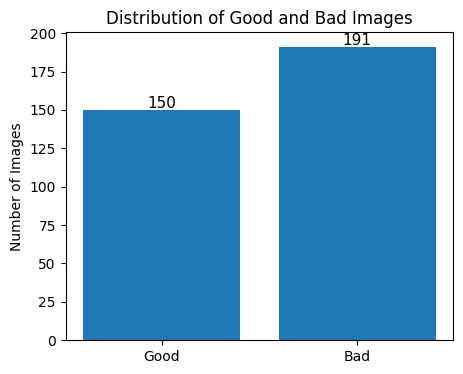

In [12]:


# Retrieve all image paths from the train, validation, and test sets.
image_paths = []

for folder in ["train", "valid", "test"]:
    image_paths.extend(glob(os.path.join(dataset_path, folder, "images", "*")))

# Count the number of good and bad images based on the filename prefix.
good_images = sum(
    1 for img in image_paths
    if os.path.basename(img).startswith("good_")
)

bad_images = sum(
    1 for img in image_paths
    if os.path.basename(img).startswith("bad_")
)

total_images = good_images + bad_images

# Display the dataset distribution.
print(f"Total Images : {total_images}")
print(f"Good Images  : {good_images} ({good_images/total_images:.2%})")
print(f"Bad Images   : {bad_images} ({bad_images/total_images:.2%})")

# Determine whether the dataset is balanced.
ratio = max(good_images, bad_images) / min(good_images, bad_images)

print("\nDataset Analysis")
print("-" * 30)

if ratio <= 1.2:
    print("The dataset is Balanced.")
else:
    print("The dataset is Imbalanced.")

# Visualize the class distribution.
plt.figure(figsize=(5, 4))
plt.bar(["Good", "Bad"], [good_images, bad_images])

plt.title("Distribution of Good and Bad Images")
plt.ylabel("Number of Images")

# Display the count on top of each bar.
for i, count in enumerate([good_images, bad_images]):
    plt.text(i, count + 1, str(count), ha='center', fontsize=11)

plt.show()

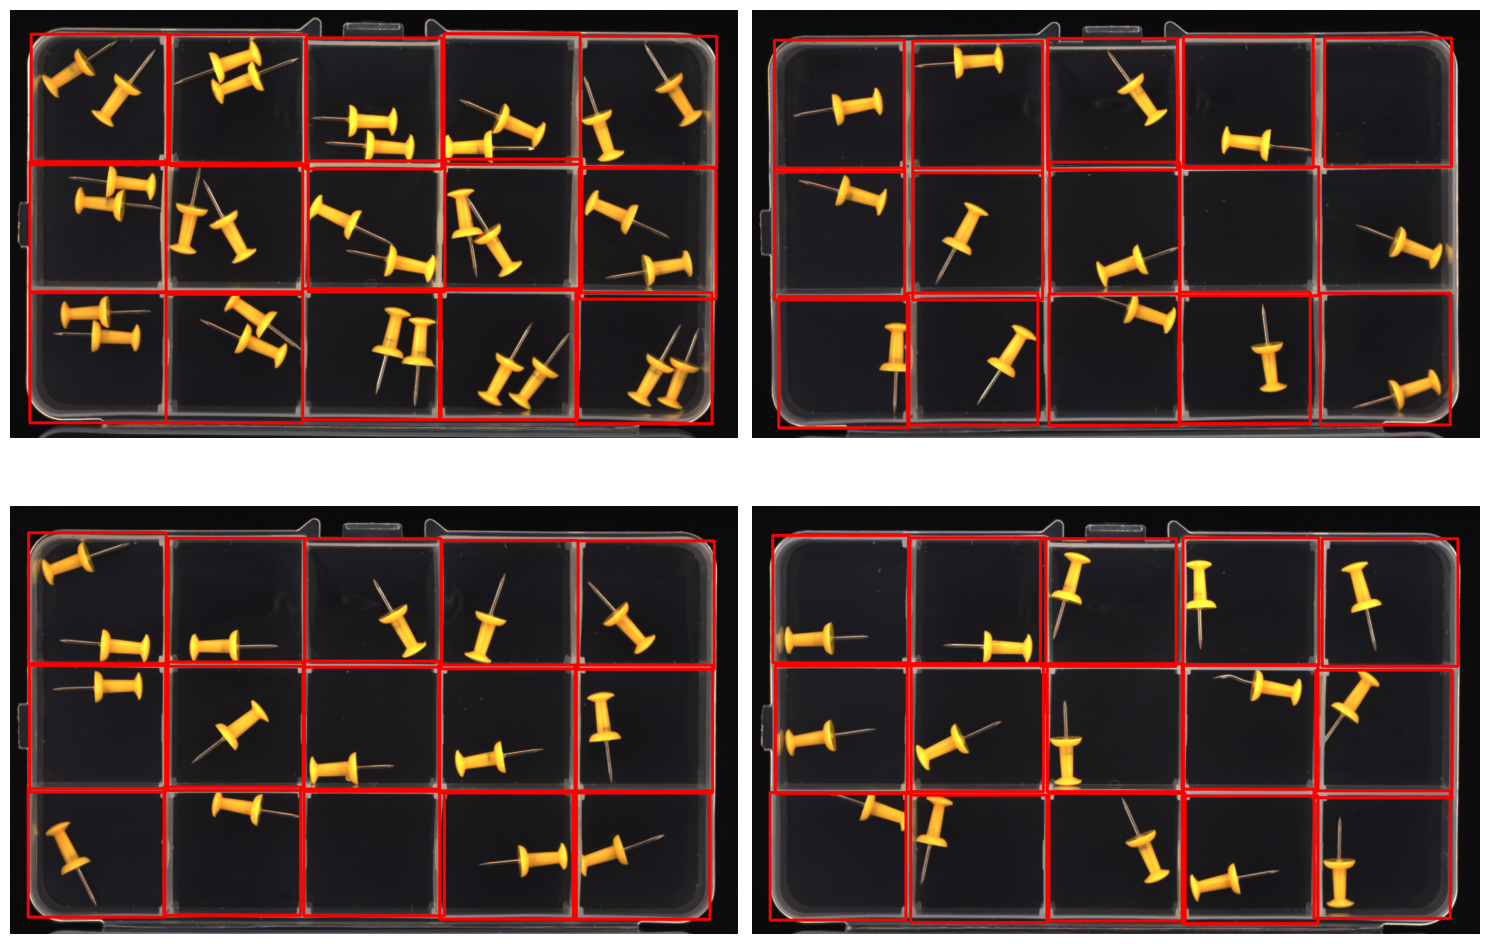

In [13]:
# Visualize a random sample of annotated training images.
# This step helps verify that the bounding boxes and class
# labels have been correctly annotated before training the
# object detection model. Four images are randomly selected
# from the training dataset and displayed with their
# corresponding bounding boxes.

plot(
    image_paths='/content/drive/MyDrive/pins/train/images/',
    label_paths='/content/drive/MyDrive/pins/train/labels/',
    num_samples=4,
)

# **2. Model Training**

# Model Training (8 Marks)

## 1. Transfer Learning

A pre-trained object detection model was fine-tuned using **Ultralytics YOLOv8** instead of training the network from scratch. Transfer learning enables the model to leverage features learned from large-scale datasets, resulting in faster convergence and improved detection performance.

## 2. Model Experiments

Multiple experiments were conducted to identify the best-performing object detection model.

### Experiment 1: YOLOv8s (Baseline Model)

- Pre-trained **YOLOv8s** model.
- Default training configuration.
- Used as the baseline for performance comparison.

### Experiment 2: YOLOv8n with Data Augmentation

The **YOLOv8n** model was trained using several data augmentation techniques to improve model robustness and generalization.

The following augmentations were applied:

- HSV Hue augmentation
- HSV Saturation augmentation
- HSV Value augmentation
- Rotation
- Translation
- Scaling
- Shearing
- Horizontal flipping
- Mosaic augmentation

### Experiment 3: YOLOv8n with Hyperparameter Tuning

The **YOLOv8n** model was further optimized by modifying several training hyperparameters, including:

- Image size
- Batch size
- Learning rate

These changes were intended to improve the detection accuracy and overall model performance.

## 3. Model Evaluation

Each trained model was evaluated using standard object detection metrics, including:

- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95

These metrics were used to assess the detection accuracy and localization performance of each model.

## 4. Model Comparison

The performance of all trained models was compared based on the evaluation metrics.

The comparison considered:

- Detection accuracy
- Precision
- Recall
- Mean Average Precision (mAP)
- Overall robustness

## 5. Best Model Selection

Based on the comparative evaluation, the model with the best overall performance was selected as the final object detection model.

The selected model was then used for the final evaluation on the unseen test dataset and for implementing the box acceptance and rejection logic.

# **Dataset YAML File**

In [15]:
# Create the YOLO dataset configuration file (data.yaml).
# This file provides the information required by Ultralytics
# YOLO to locate the dataset and understand the object classes.
#
# It specifies:
# - The root directory of the dataset.
# - The locations of the training, validation, and test images.
# - The total number of object classes.
# - The class names corresponding to each class ID.

%%writefile data.yaml

# Root dataset directory
path: /content/drive/MyDrive/CV_pin_dataset

# Training image directory
train: train/images

# Validation image directory
val: valid/images

# Test image directory
test: test/images

# Total number of object classes
nc: 9

# Class names
names:
  0: 1_pin
  1: 2_pin
  2: 3_pin
  3: missing_pin
  4: front_bend
  5: broken
  6: wrong_color
  7: contamination
  8: missing_separator

Writing data.yaml


In [ ]:
# Install the Ultralytics package, which provides the YOLOv8
# framework for object detection. This library includes
# pre-trained models, training utilities, inference functions,
# and evaluation tools required to build and assess the object
# detection model.

!pip install ultralytics

# **Experiment 1: YOLOv8 Nano (Baseline)**

In [ ]:


# Load the pre-trained YOLOv8s model.
# Transfer learning is performed by fine-tuning the
# pre-trained weights on the custom pin defect dataset.
model = YOLO("yolov8s.pt")

# Train the model using the custom dataset.
#
# Training configuration:
# - data     : Dataset configuration file.
# - epochs   : Number of training iterations.
# - imgsz    : Input image size.
# - batch    : Number of images processed in each batch.
# - project  : Directory where training results are saved.
# - name     : Name of the current training experiment.
model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="CV_Pin",
    name="YOLOv8s"
)

# Evaluate the trained model on the validation dataset.
# The evaluation computes standard object detection metrics.
metrics = model.val()

# Display the Mean Average Precision at IoU = 0.5.
print("mAP50:", metrics.box.map50)

# Display the Mean Average Precision averaged over
# IoU thresholds from 0.5 to 0.95.
print("mAP50-95:", metrics.box.map)

# Display the overall precision of the detector.
print("Precision:", metrics.box.mp)

# Display the overall recall of the detector.
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=

# **Experiment 2: YOLOv8 Small**

In [ ]:


# Load the pre-trained YOLOv8s model.
# The model is fine-tuned on the custom pin defect dataset
# using transfer learning instead of training from scratch.
model = YOLO("yolov8s.pt")

# Train the YOLOv8s model using the custom dataset.
# The training configuration uses:
# - 10 training epochs
# - Image size of 640 × 640 pixels
# - Batch size of 16 images
# The trained model weights, logs, and results are saved
# under the specified project and experiment name.
model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    project="CV_Pin",
    name="YOLOv8s"
)

# Evaluate the trained model on the validation dataset
# to measure its object detection performance.
metrics = model.val()

# Display the Mean Average Precision (mAP) at an IoU threshold of 0.50.
print("mAP50:", metrics.box.map50)

# Display the Mean Average Precision averaged over IoU thresholds
# from 0.50 to 0.95.
print("mAP50-95:", metrics.box.map)

# Display the overall precision of the trained model.
print("Precision:", metrics.box.mp)

# Display the overall recall of the trained model.
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8s-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

# **Experiment 3: Same architecture + Data Augmentation**

In [ ]:


# Load the pre-trained YOLOv8n model.
# This experiment investigates the effect of data augmentation
# on object detection performance using transfer learning.
model = YOLO("yolov8n.pt")

# Train the model with various data augmentation techniques
# to improve robustness and generalization.
#
# Augmentations applied:
# - HSV hue, saturation, and value adjustments
# - Random image rotation
# - Random translation
# - Random scaling
# - Random shearing
# - Horizontal flipping
# - Mosaic augmentation
#
# The trained model and training logs are saved under the
# specified project and experiment name.
model.train(
    data="data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,

    # Color augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Geometric augmentation
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2,
    fliplr=0.5,

    # Mosaic augmentation
    mosaic=1.0,

    project="CV_Pin",
    name="YOLOv8n_Augmented"
)

# Evaluate the trained model on the validation dataset.
metrics = model.val()

# Display the Mean Average Precision (mAP) at IoU = 0.50.
print("mAP50:", metrics.box.map50)

# Display the Mean Average Precision averaged over
# IoU thresholds from 0.50 to 0.95.
print("mAP50-95:", metrics.box.map)

# Display the overall precision of the trained model.
print("Precision:", metrics.box.mp)

# Display the overall recall of the trained model.
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Augmented, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, per

# **Experiment 4: Hyperparameter Tuning**

In [ ]:


# Load the pre-trained YOLOv8n model.
# This experiment evaluates the effect of hyperparameter tuning
# on the object detection performance using transfer learning.
model = YOLO("yolov8n.pt")

# Train the model with modified hyperparameters.
#
# Hyperparameters adjusted:
# - epochs : Number of training iterations.
# - imgsz  : Increased input image size to capture finer details.
# - batch  : Reduced batch size to accommodate the larger image size.
# - lr0    : Initial learning rate used by the optimizer.
#
# The trained model, logs, and evaluation results are saved
# under the specified project and experiment name.
model.train(
    data="data.yaml",

    # Training hyperparameters
    epochs=10,
    imgsz=800,
    batch=8,
    lr0=0.005,

    project="CV_Pin",
    name="YOLOv8n_Tuned"
)

# Evaluate the trained model on the validation dataset
# using standard object detection metrics.
metrics = model.val()

# Display the Mean Average Precision (mAP) at an IoU threshold of 0.50.
print("mAP50:", metrics.box.map50)

# Display the Mean Average Precision averaged over
# IoU thresholds from 0.50 to 0.95.
print("mAP50-95:", metrics.box.map)

# Display the overall precision of the trained model.
print("Precision:", metrics.box.mp)

# Display the overall recall of the trained model.
print("Recall:", metrics.box.mr)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8n_Tuned, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

# **Evaluate YOLOv8s model**

In [ ]:


# Load the best-performing weights obtained after training
# the YOLOv8s model. The model saved as 'best.pt' corresponds
# to the checkpoint with the highest validation performance.
model = YOLO("runs/detect/CV_Pin/YOLOv8s/weights/best.pt")

# Evaluate the trained model on the unseen test dataset.
# The test set was not used during training or validation,
# providing an unbiased assessment of the model's
# generalization performance.
metrics = model.val(
    data="data.yaml",
    split="test"
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 1.9±0.5 MB/s, size: 1453.4 KB)
val: Scanning /content/drive/MyDrive/CV_pin_dataset/test/labels... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 1.2s/it 39.4s
val: New cache created: /content/drive/MyDrive/CV_pin_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.6s
                   all         33        131      0.944      0.314      0.394      0.347
                 1_pin         19         94          1          0      0.182      0.145
                 2_pin          4         19       0.94      0.827      0.948      0.803
                 3_pin          1          1          1          0      0.166      0.166
           missing_pin          5          6      0

# **Evaluate YOLOv8n_Tuned**

In [ ]:
# Load the best-performing weights obtained from the
# YOLOv8n model after hyperparameter tuning.
# The 'best.pt' checkpoint corresponds to the model
# that achieved the highest validation performance
# during training.
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

# Evaluate the trained model on the unseen test dataset.
# This evaluation provides an unbiased estimate of the
# model's performance using images that were not seen
# during training or validation.
metrics = model.val(
    data="data.yaml",
    split="test"
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 294.2±80.8 MB/s, size: 1467.9 KB)
val: Scanning /content/drive/MyDrive/CV_pin_dataset/test/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 10.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.0s/it 3.0s
                   all         33        131        0.8     0.0883       0.14      0.121
                 1_pin         19         94      0.136      0.532      0.135     0.0934
                 2_pin          4         19     0.0635      0.263     0.0802     0.0643
                 3_pin          1          1          1          0          0          0
           missing_pin          5          6          1          0    0.00941     0.0057
            front_bend          2 

# **Evaluate YOLOv8n_Augmented**

In [ ]:
# Load the best-performing weights obtained from the
# YOLOv8n model trained with data augmentation.
# The 'best.pt' checkpoint represents the model that
# achieved the highest validation performance during training.
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Augmented/weights/best.pt")

# Evaluate the trained model on the unseen test dataset.
# The test set contains images that were not used during
# training or validation, allowing the model's
# generalization performance to be assessed.
metrics = model.val(
    data="data.yaml",
    split="test"
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 325.9±60.3 MB/s, size: 1454.8 KB)
val: Scanning /content/drive/MyDrive/CV_pin_dataset/test/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 9.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1it/s 2.7s
                   all         33        131      0.834      0.269      0.257      0.219
                 1_pin         19         94      0.115      0.734      0.176      0.131
                 2_pin          4         19      0.394          1      0.951      0.777
                 3_pin          1          1          1          0      0.142      0.128
           missing_pin          5          6          1          0     0.0137     0.0117
            front_bend          2  

# **Evaluate YOLOv8s-2**

In [ ]:
# Load the best-performing weights obtained from the
# second YOLOv8s training experiment.
# The 'best.pt' checkpoint corresponds to the model that
# achieved the highest validation performance during training.
model = YOLO("runs/detect/CV_Pin/YOLOv8s-2/weights/best.pt")

# Evaluate the trained model on the unseen test dataset.
# This provides an unbiased assessment of the model's
# detection performance on images that were not used
# during training or validation.
metrics = model.val(
    data="data.yaml",
    split="test"
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,129,067 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 388.4±36.8 MB/s, size: 1470.3 KB)
val: Scanning /content/drive/MyDrive/CV_pin_dataset/test/labels.cache... 23 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 23/23 5.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.0s/it 2.1s
                   all         23         44      0.248      0.419      0.237      0.215
                 1_pin          6         20     0.0453        0.8     0.0614     0.0539
                 2_pin          3          3      0.126      0.667      0.131      0.118
           missing_pin          5          9      0.357      0.889      0.489      0.435
            front_bend          2          2          1          0    0.00975    0.00878
                broken          3

# **3.Model Evaluation**

# Model Evaluation (5 Marks)

## 1. Final Model Evaluation

The best-performing object detection model was evaluated using the **unseen test dataset**. The test set was not used during training or validation, ensuring an unbiased assessment of the model's generalization performance.

## 2. Performance Metrics

The model performance was assessed using the following object detection metrics:

- **Precision** – Measures the proportion of correctly detected objects among all predicted objects.
- **Recall** – Measures the proportion of correctly detected objects among all ground truth objects.
- **mAP@0.5** – Mean Average Precision at an Intersection over Union (IoU) threshold of 0.50.
- **mAP@0.5:0.95** – Mean Average Precision averaged across IoU thresholds ranging from 0.50 to 0.95.

These metrics provide a comprehensive evaluation of both the classification and localization performance of the object detection model.

## 3. Precision–Recall Curve

A **Precision–Recall (PR) Curve** was generated to visualize the relationship between precision and recall across different confidence thresholds.

The PR curve provides insight into the model's detection performance and illustrates the trade-off between identifying more objects (higher recall) and reducing false detections (higher precision).

## 4. Confusion Matrix

A **Confusion Matrix** was generated to evaluate the classification performance of the trained model across all object classes.

The confusion matrix helps identify:

- Correctly classified objects.
- Misclassified object classes.
- Classes that are frequently confused with one another.
- Overall strengths and weaknesses of the detector.

## 5. Performance Analysis

The evaluation metrics and visualizations were analyzed to assess the effectiveness of the trained object detection model. The final model was selected based on its overall detection accuracy, precision, recall, and mean Average Precision (mAP) on the unseen test dataset.

# **Load the Best Model**

In [ ]:


# Load the best-performing YOLOv8n model obtained after
# hyperparameter tuning. The 'best.pt' checkpoint contains
# the model weights that achieved the highest validation
# performance during training and will be used for the
# final evaluation and inference.

model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

# **Evaluate on the Test Set**

In [ ]:
# Evaluate the final trained model using the unseen test dataset.
# The test set was not used during training or validation,
# ensuring an unbiased assessment of the model's performance.
#
# Setting 'save=True' stores the evaluation results, including
# performance metrics and visualizations such as the Precision–
# Recall curve, Confusion Matrix, and other evaluation plots.

metrics = model.val(
    data="data.yaml",
    split="test",
    save=True
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.0 ms, read: 305.1±30.5 MB/s, size: 1460.1 KB)
val: Scanning /content/drive/MyDrive/CV_pin_dataset/test/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 9.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.5s/it 4.6s
                   all         33        131        0.8     0.0883       0.14      0.121
                 1_pin         19         94      0.136      0.532      0.135     0.0934
                 2_pin          4         19     0.0635      0.263     0.0802     0.0643
                 3_pin          1          1          1          0          0          0
           missing_pin          5          6          1          0    0.00941     0.0057
            front_bend          2  

# **Print Performance Metrics**

In [ ]:
# Display the key object detection performance metrics
# obtained from evaluating the final model on the unseen
# test dataset.

# Mean Average Precision at an IoU threshold of 0.50.
print(f"mAP50      : {metrics.box.map50:.4f}")

# Mean Average Precision averaged over IoU thresholds
# from 0.50 to 0.95.
print(f"mAP50-95   : {metrics.box.map:.4f}")

# Overall precision of the object detector.
print(f"Precision  : {metrics.box.mp:.4f}")

# Overall recall of the object detector.
print(f"Recall     : {metrics.box.mr:.4f}")

mAP50      : 0.1401
mAP50-95   : 0.1214
Precision  : 0.8000
Recall     : 0.0883


# **Confusion matrix**

In [ ]:


# Load the trained model
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

# Evaluate on the test set
metrics = model.val(
    data="data.yaml",
    split="test"
)

# Get class names
class_names = list(model.names.values())

# Get confusion matrix
cm = metrics.confusion_matrix.matrix

# Convert to a DataFrame for better readability
cm_df = pd.DataFrame(
    cm,
    index=class_names + ["background"],
    columns=class_names + ["background"]
)

print(cm_df)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,403 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 297.4±67.1 MB/s, size: 1470.7 KB)
val: Scanning /content/drive/MyDrive/CV_pin_dataset/test/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 33/33 9.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1s/it 3.4s
                   all         33        131        0.8     0.0883       0.14      0.121
                 1_pin         19         94      0.136      0.532      0.135     0.0934
                 2_pin          4         19     0.0635      0.263     0.0802     0.0643
                 3_pin          1          1          1          0          0          0
           missing_pin          5          6          1          0    0.00941     0.0057
            front_bend          2  

# **Precision–Recall Curve**

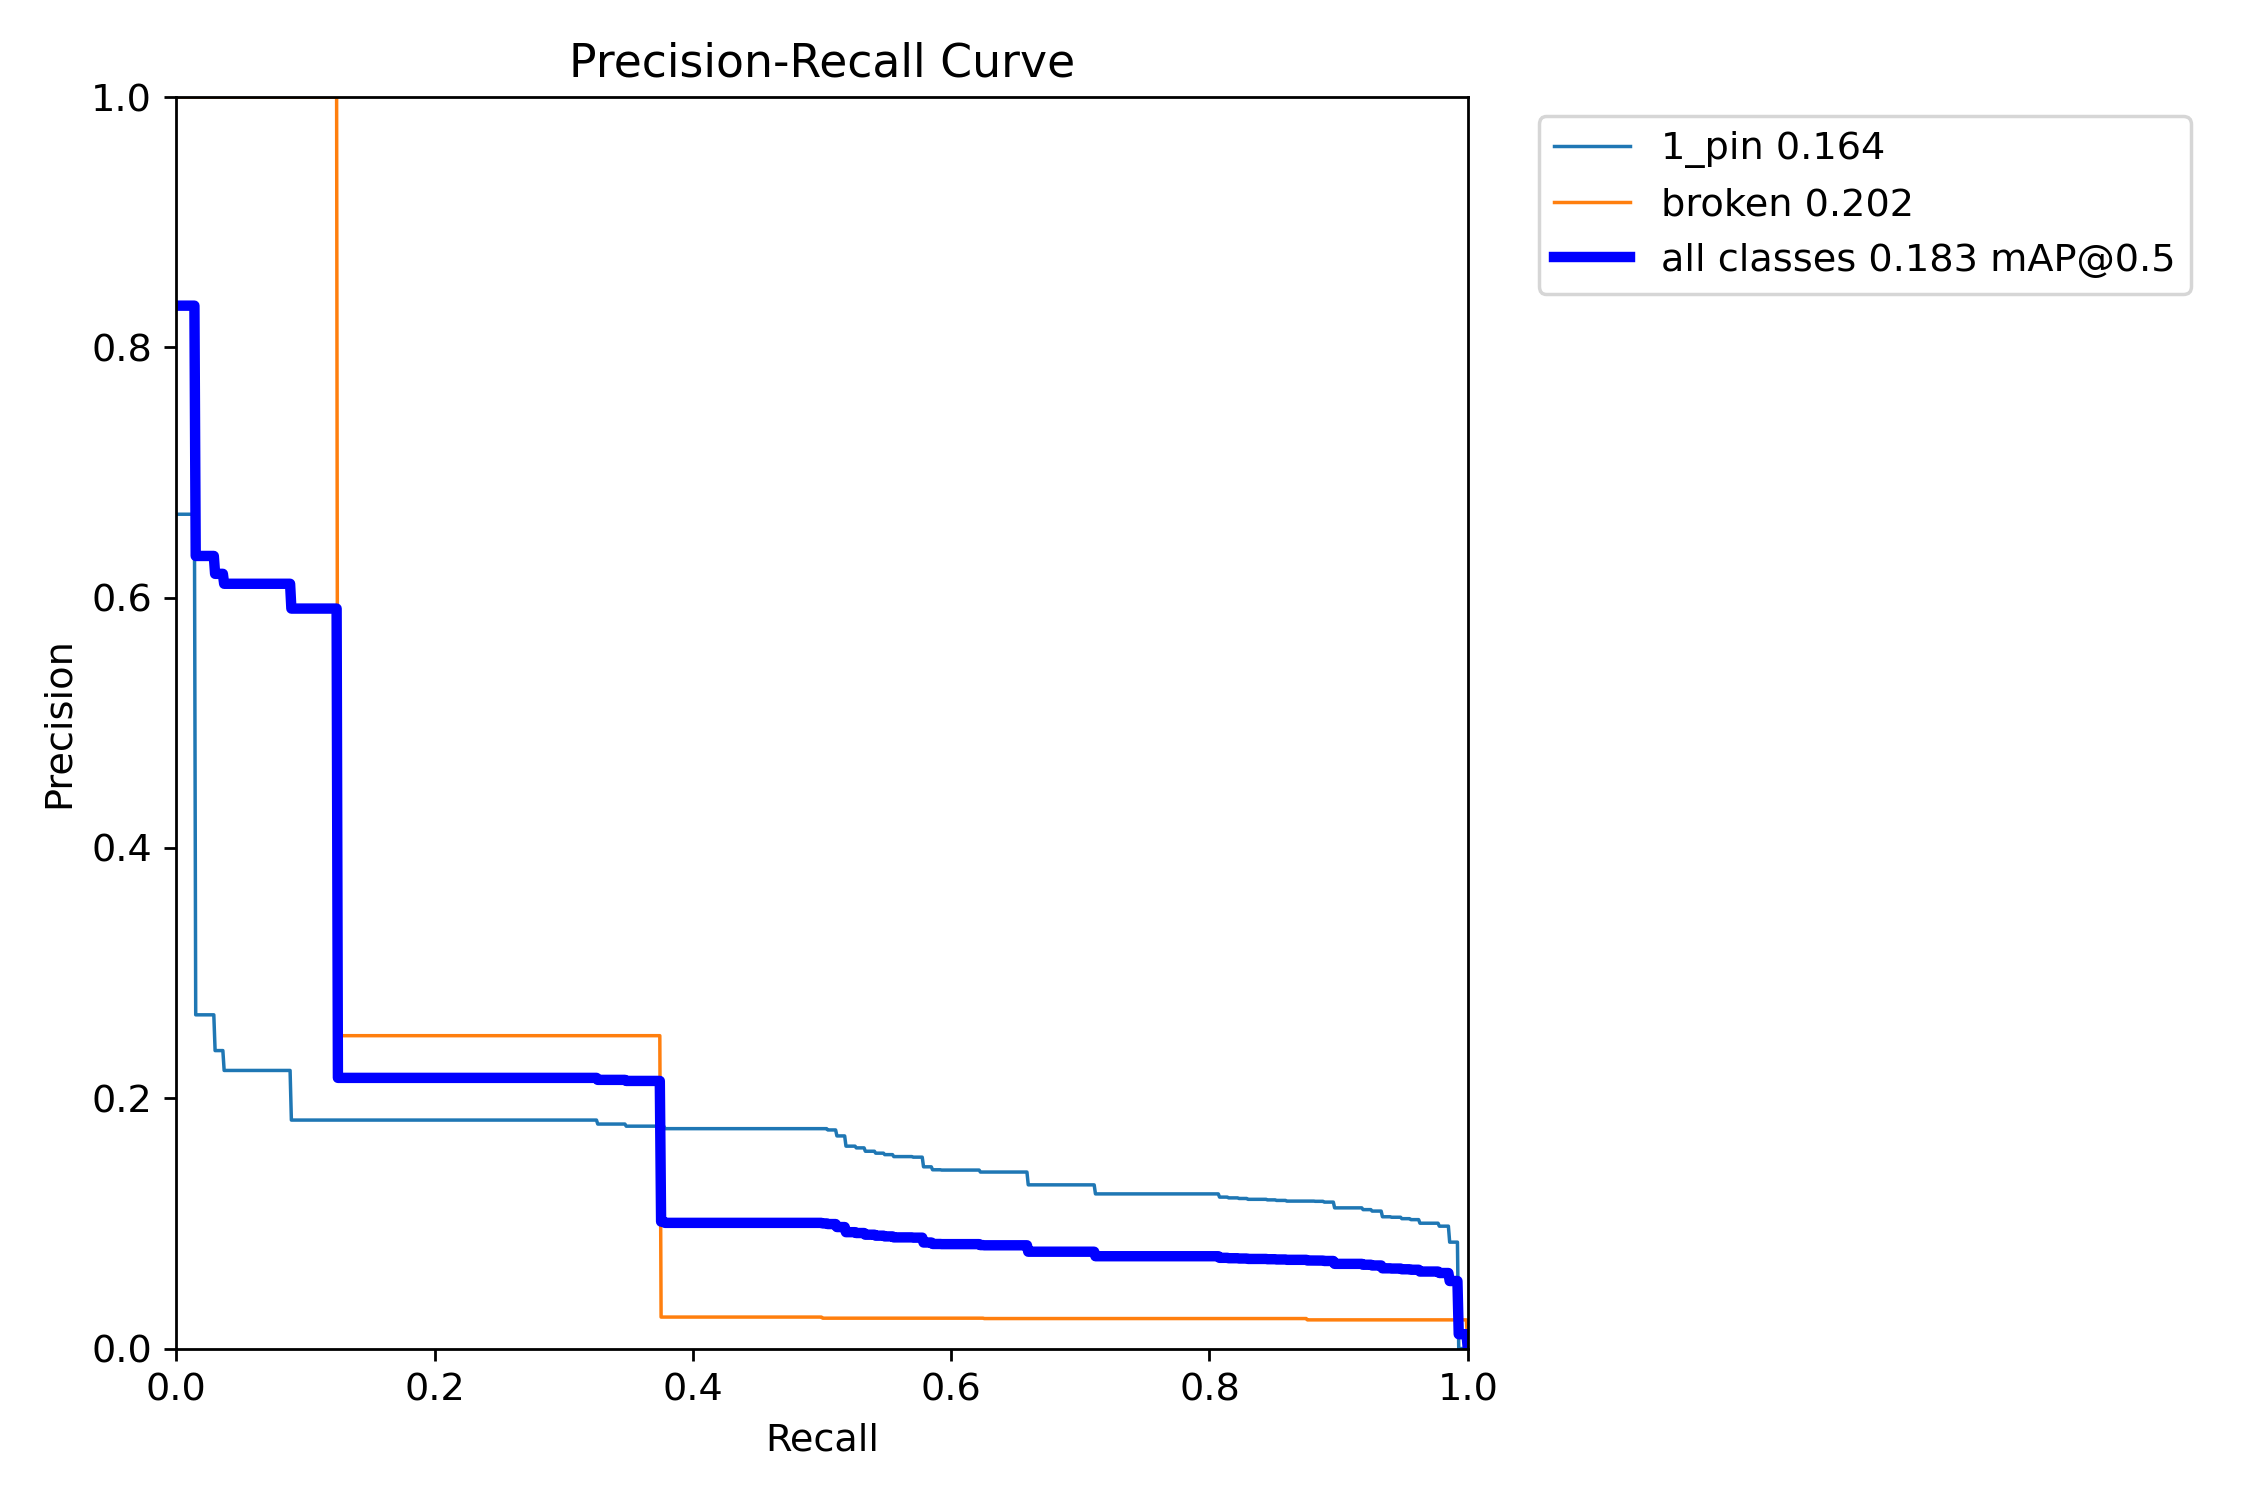

In [ ]:


# Display the Precision–Recall (PR) curve generated during
# model evaluation. The PR curve illustrates the trade-off
# between precision and recall across different confidence
# thresholds and provides insight into the detection
# performance of the trained model.

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxPR_curve.png")

# **Confusion Matrix**

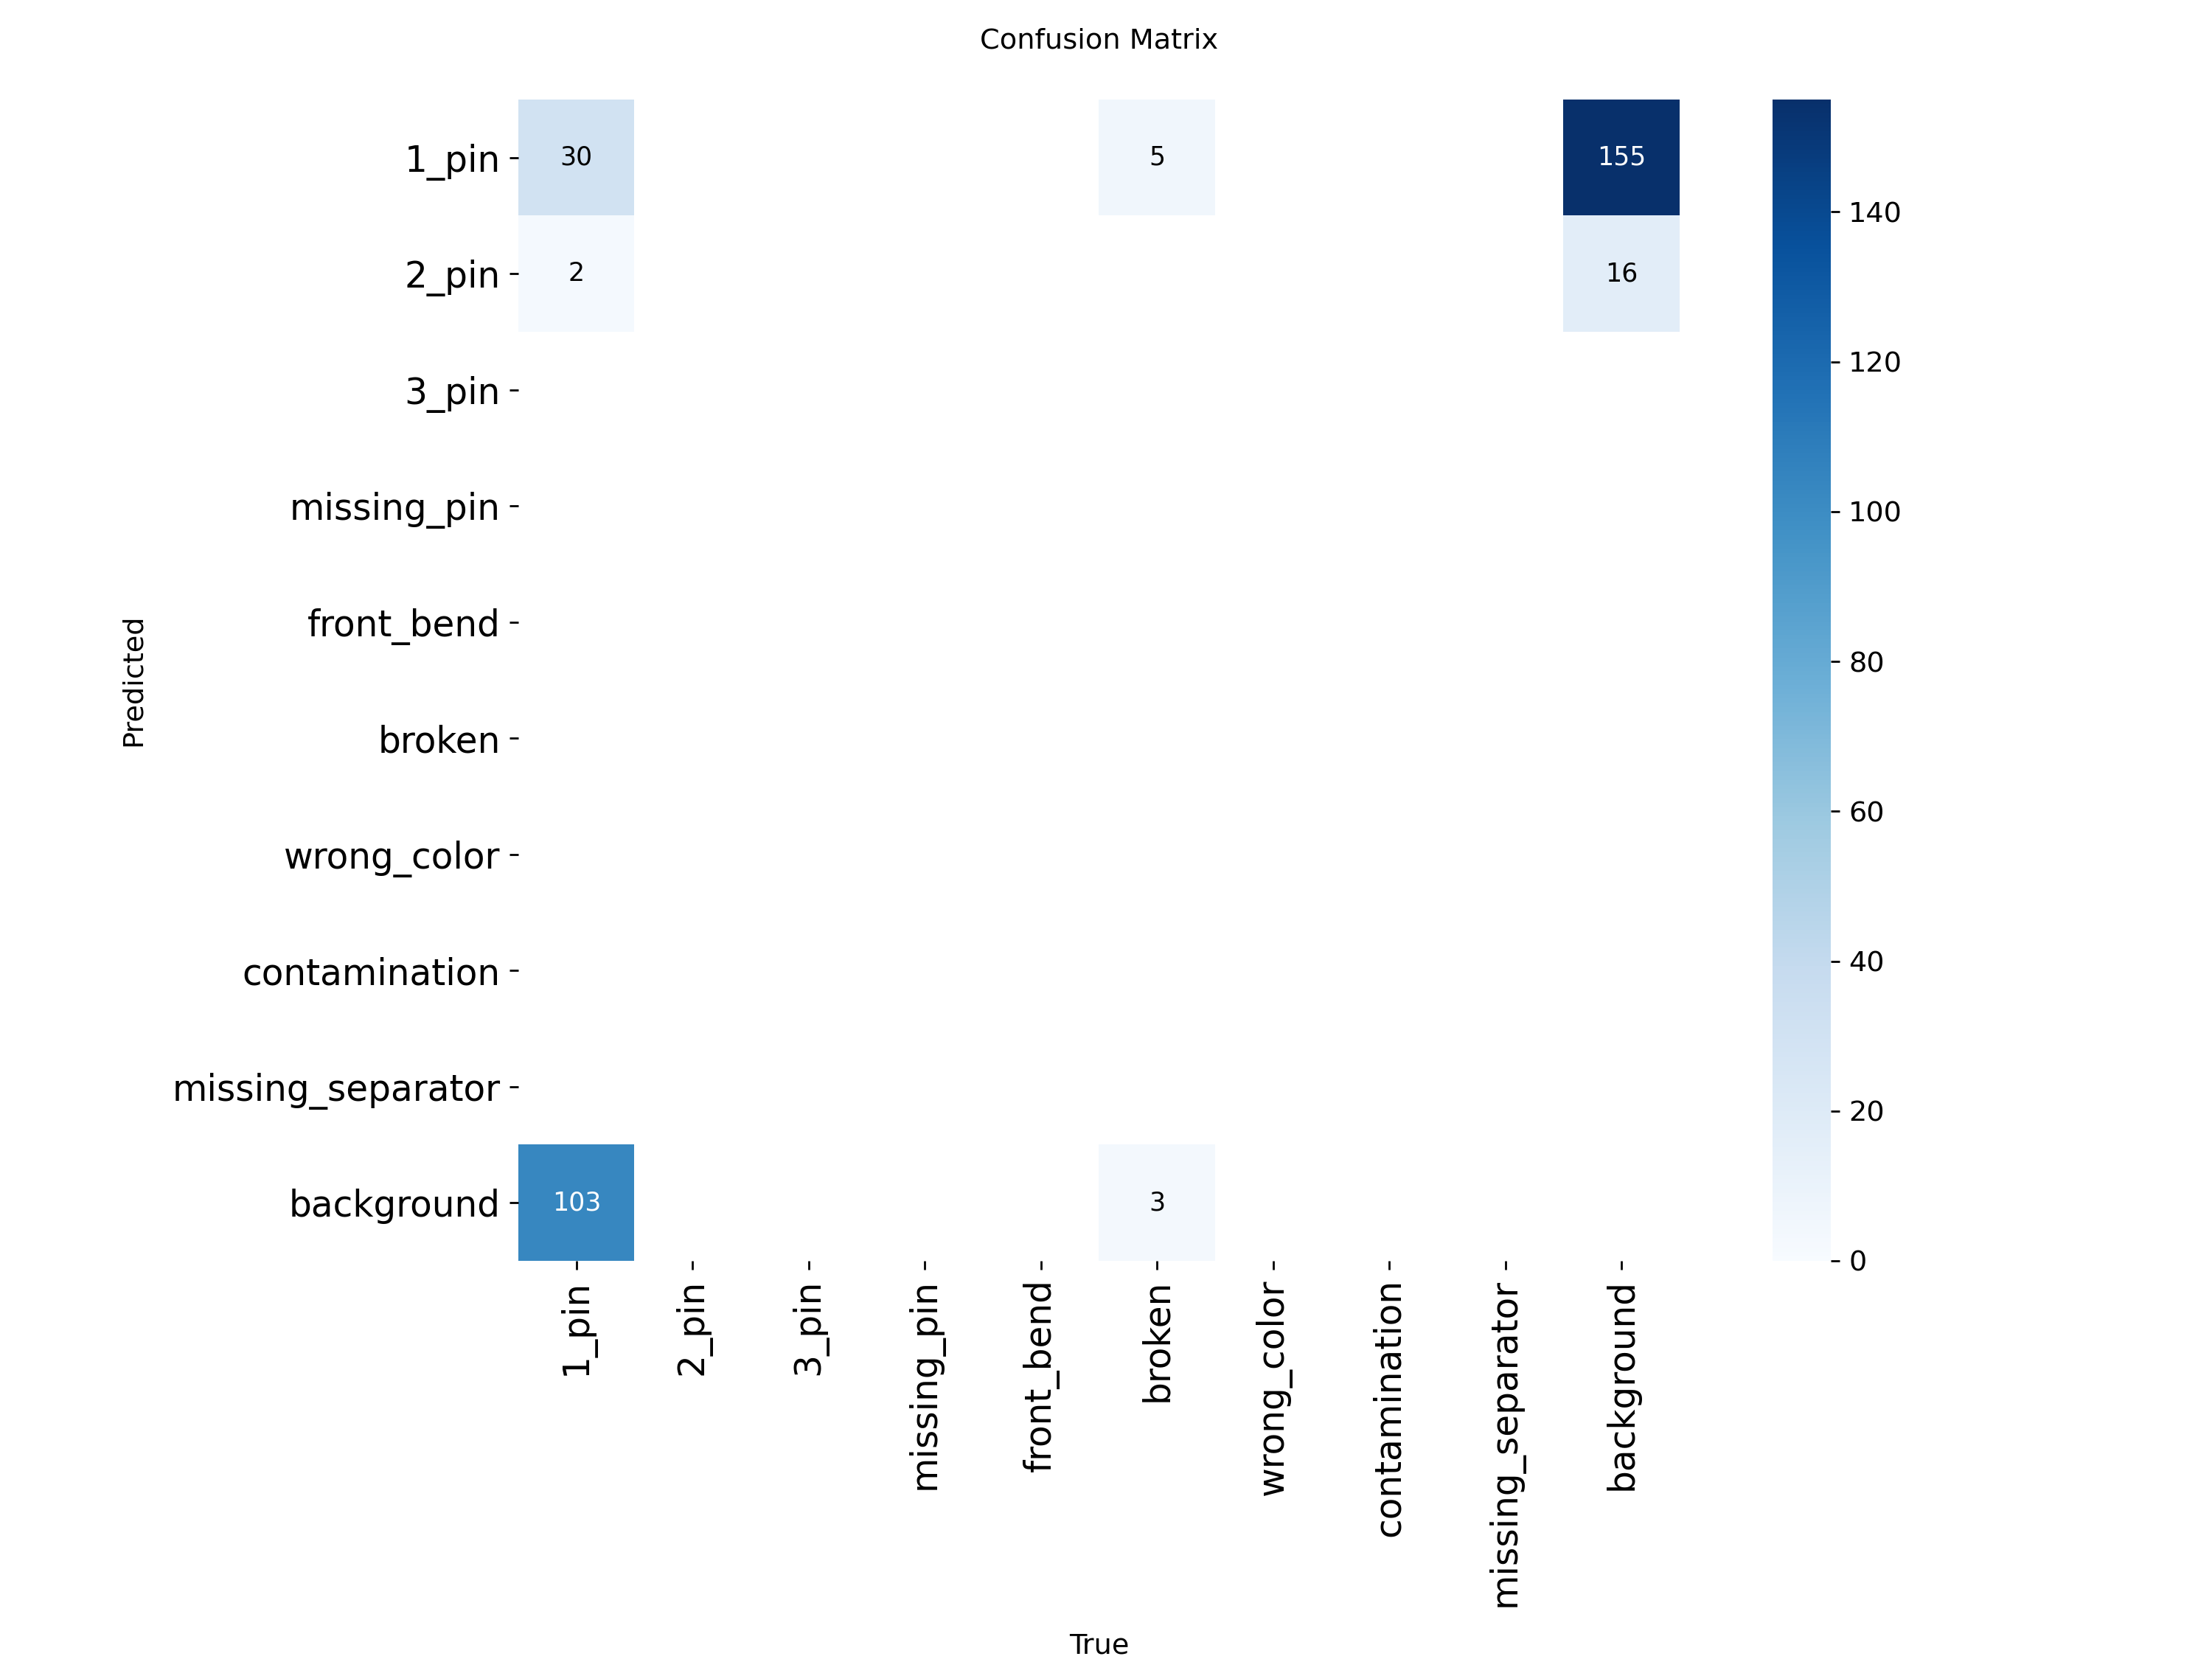

In [ ]:


# Display the confusion matrix generated during model evaluation.
# The confusion matrix summarizes the classification performance
# of the object detector by comparing the predicted object classes
# with the ground truth labels. It helps identify correctly
# classified objects as well as common misclassifications
# between different classes.

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/confusion_matrix.png")

# **Other Useful Curves**

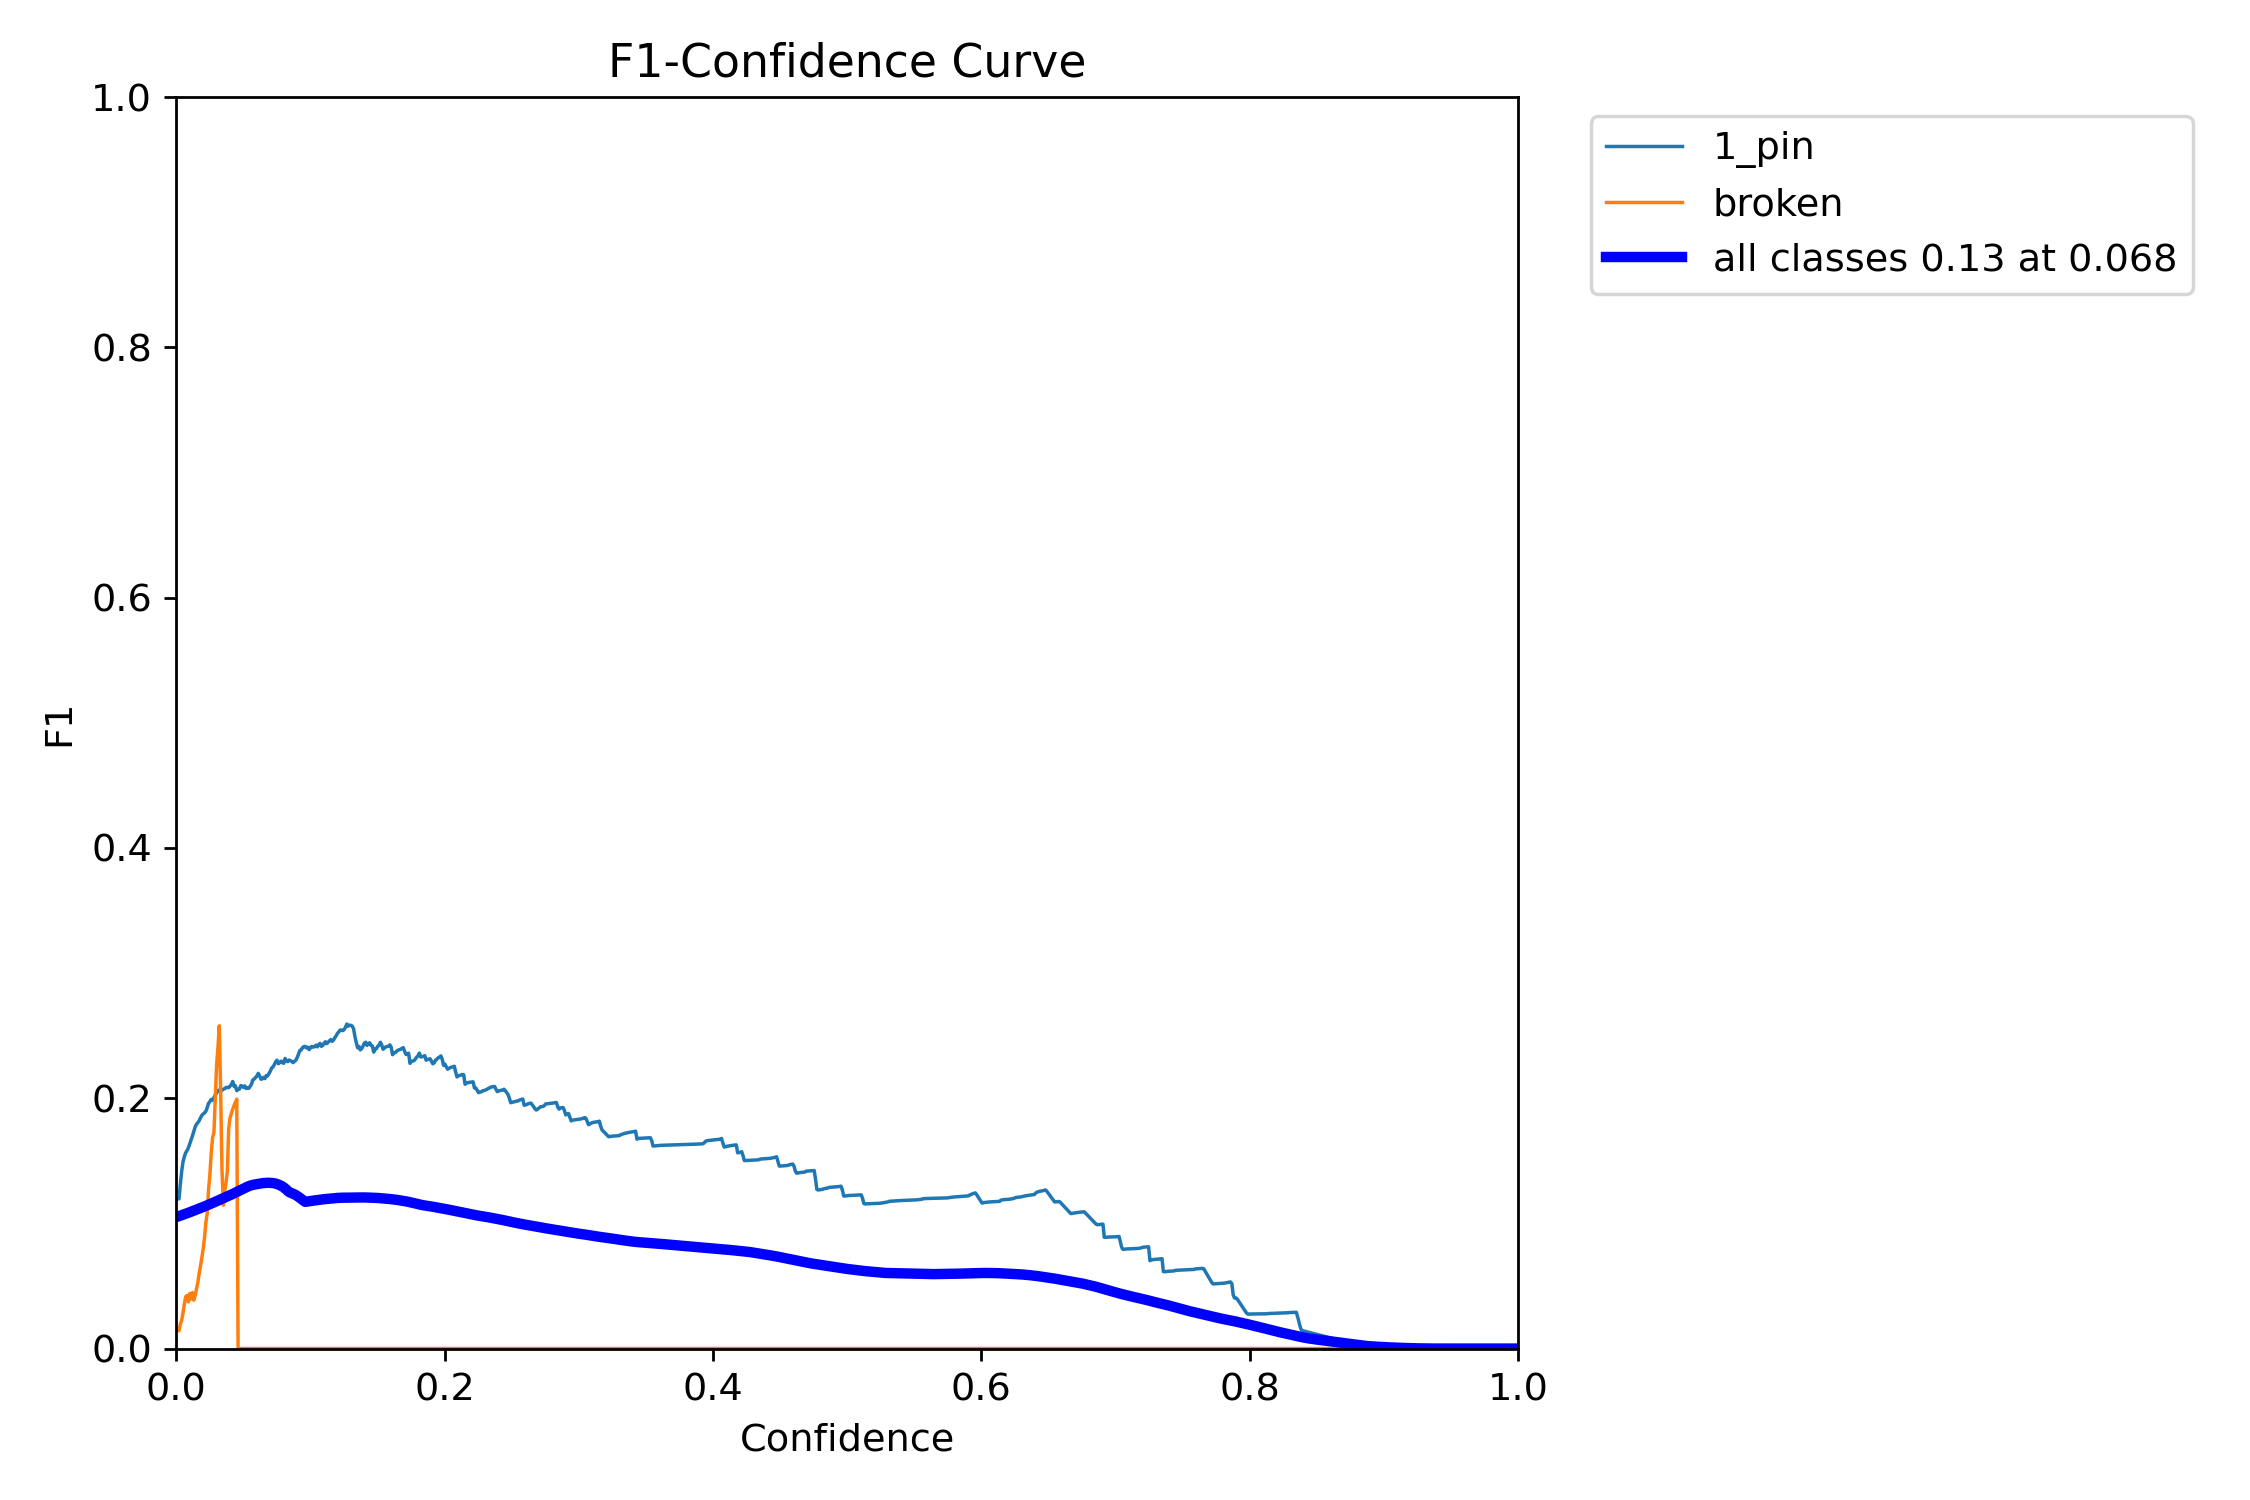

In [ ]:


# Display the F1-score curve generated during model evaluation.
# The F1-score curve illustrates how the F1-score changes across
# different confidence thresholds. Since the F1-score is the
# harmonic mean of Precision and Recall, it helps identify the
# confidence threshold that provides the best balance between
# precision and recall.

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxF1_curve.png")

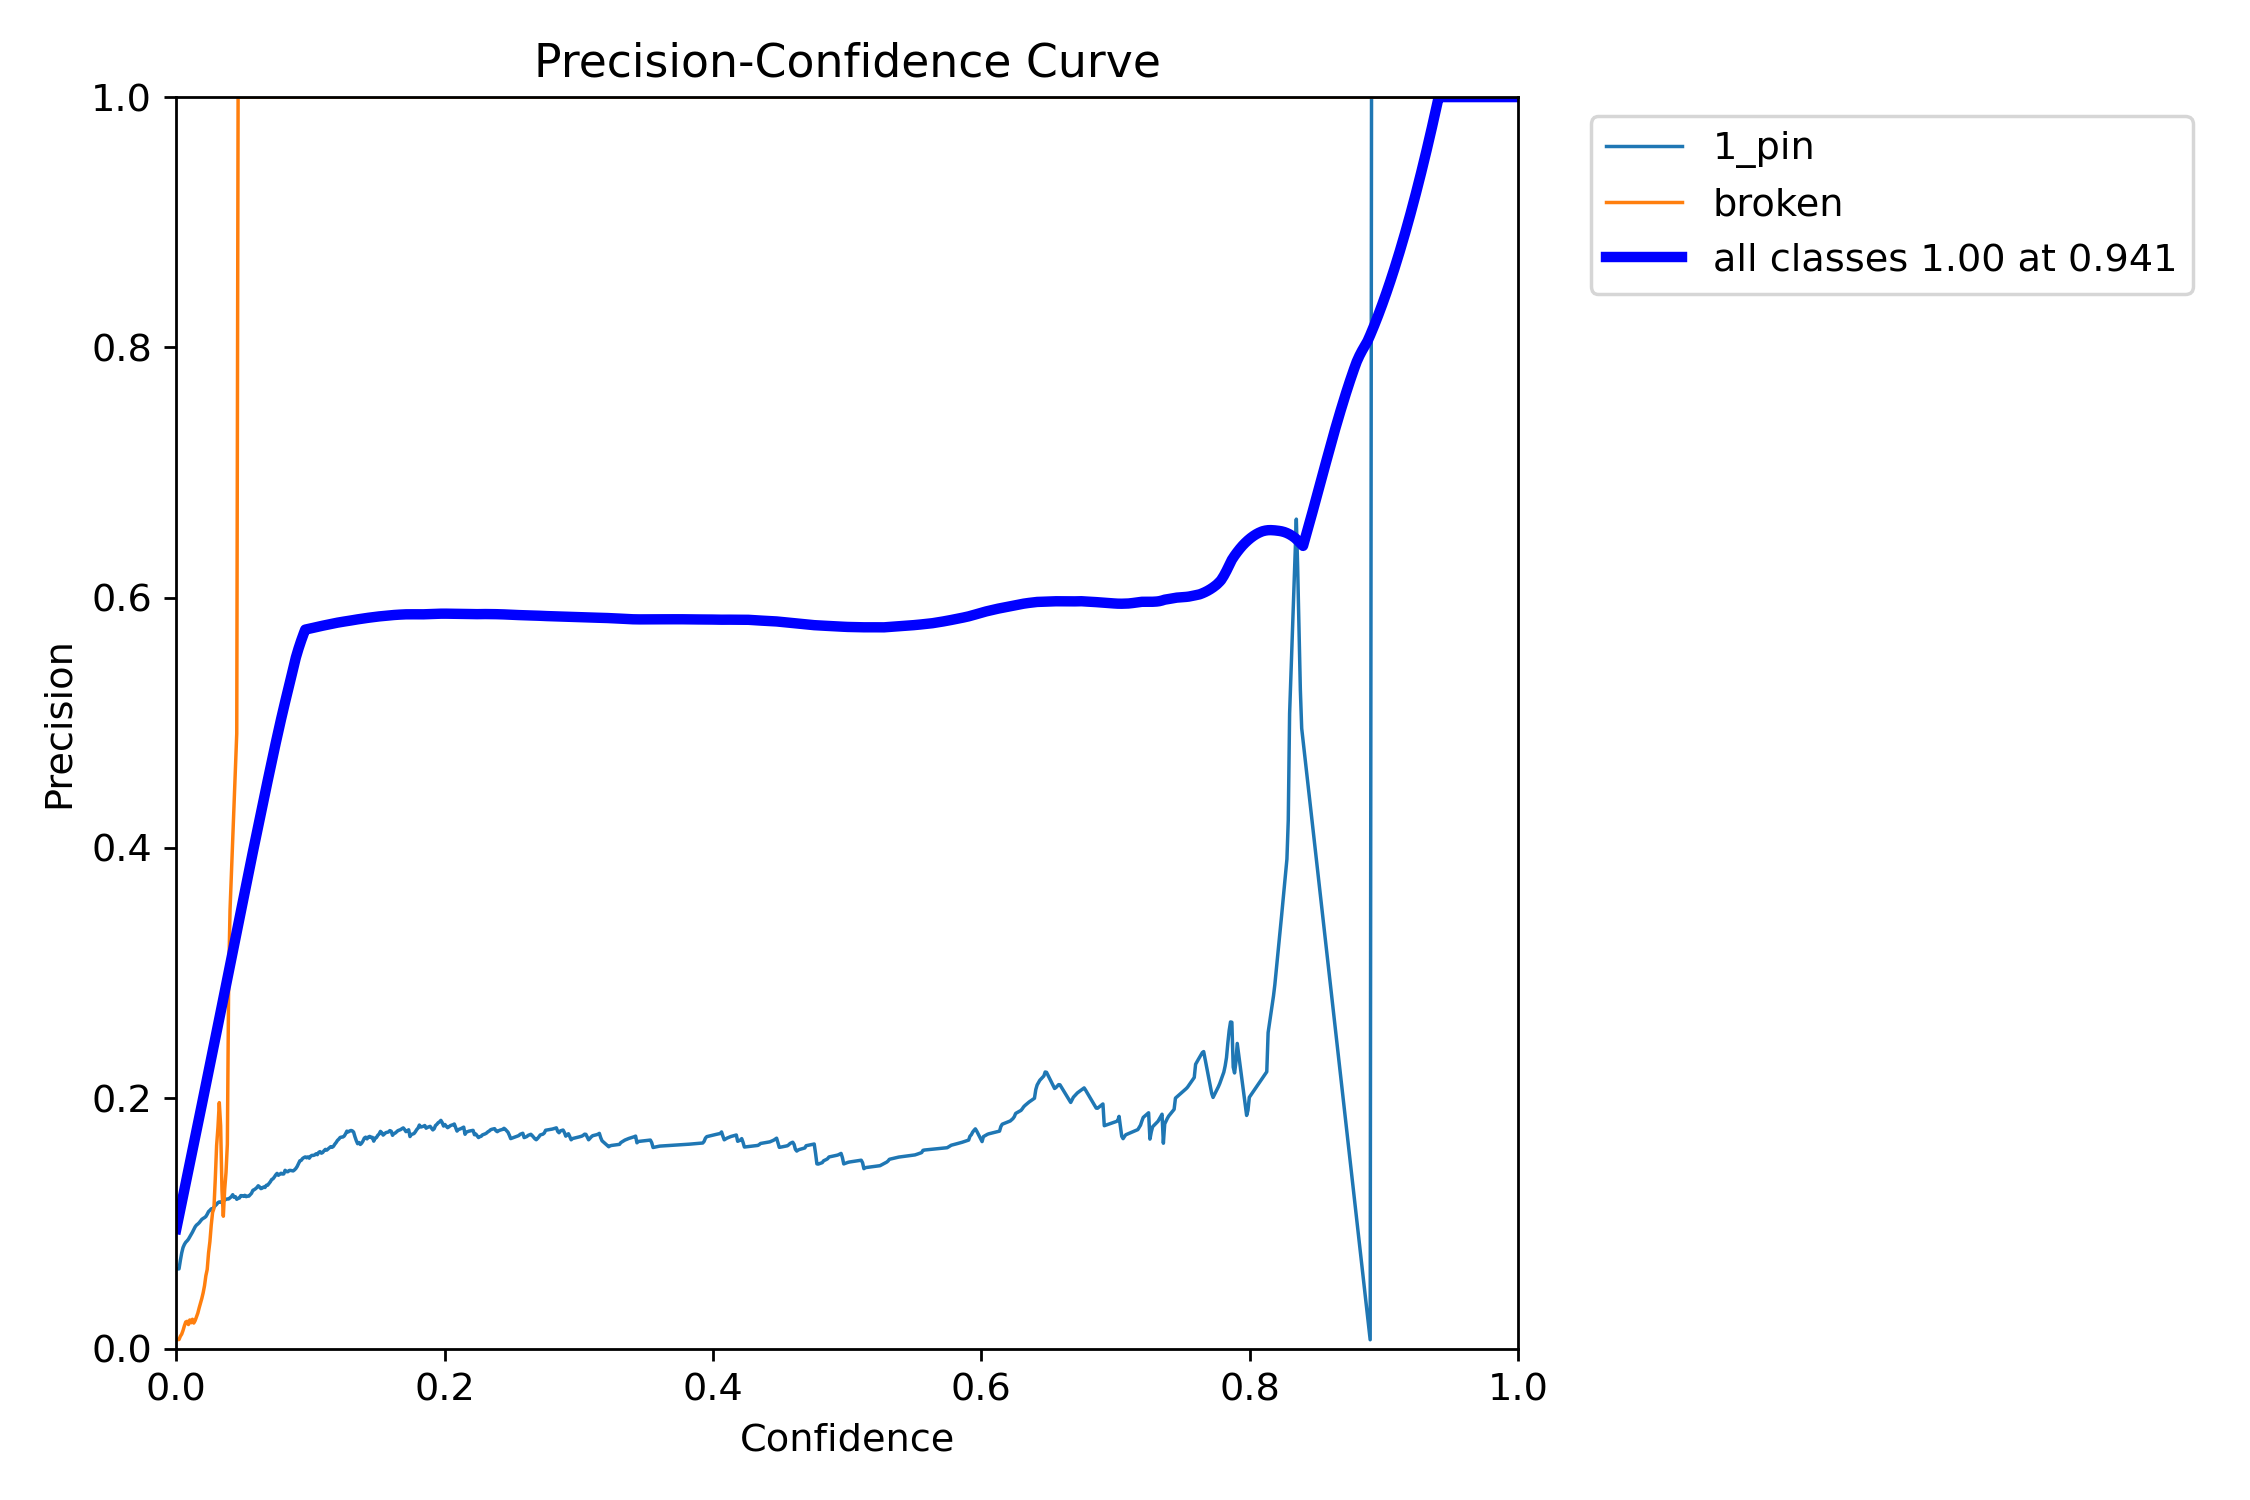

In [ ]:


# Display the Precision curve generated during model evaluation.
# The Precision curve shows how the model's precision varies
# across different confidence thresholds. It helps assess the
# proportion of predicted detections that are correct and
# provides insight into the model's false positive rate.

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxP_curve.png")

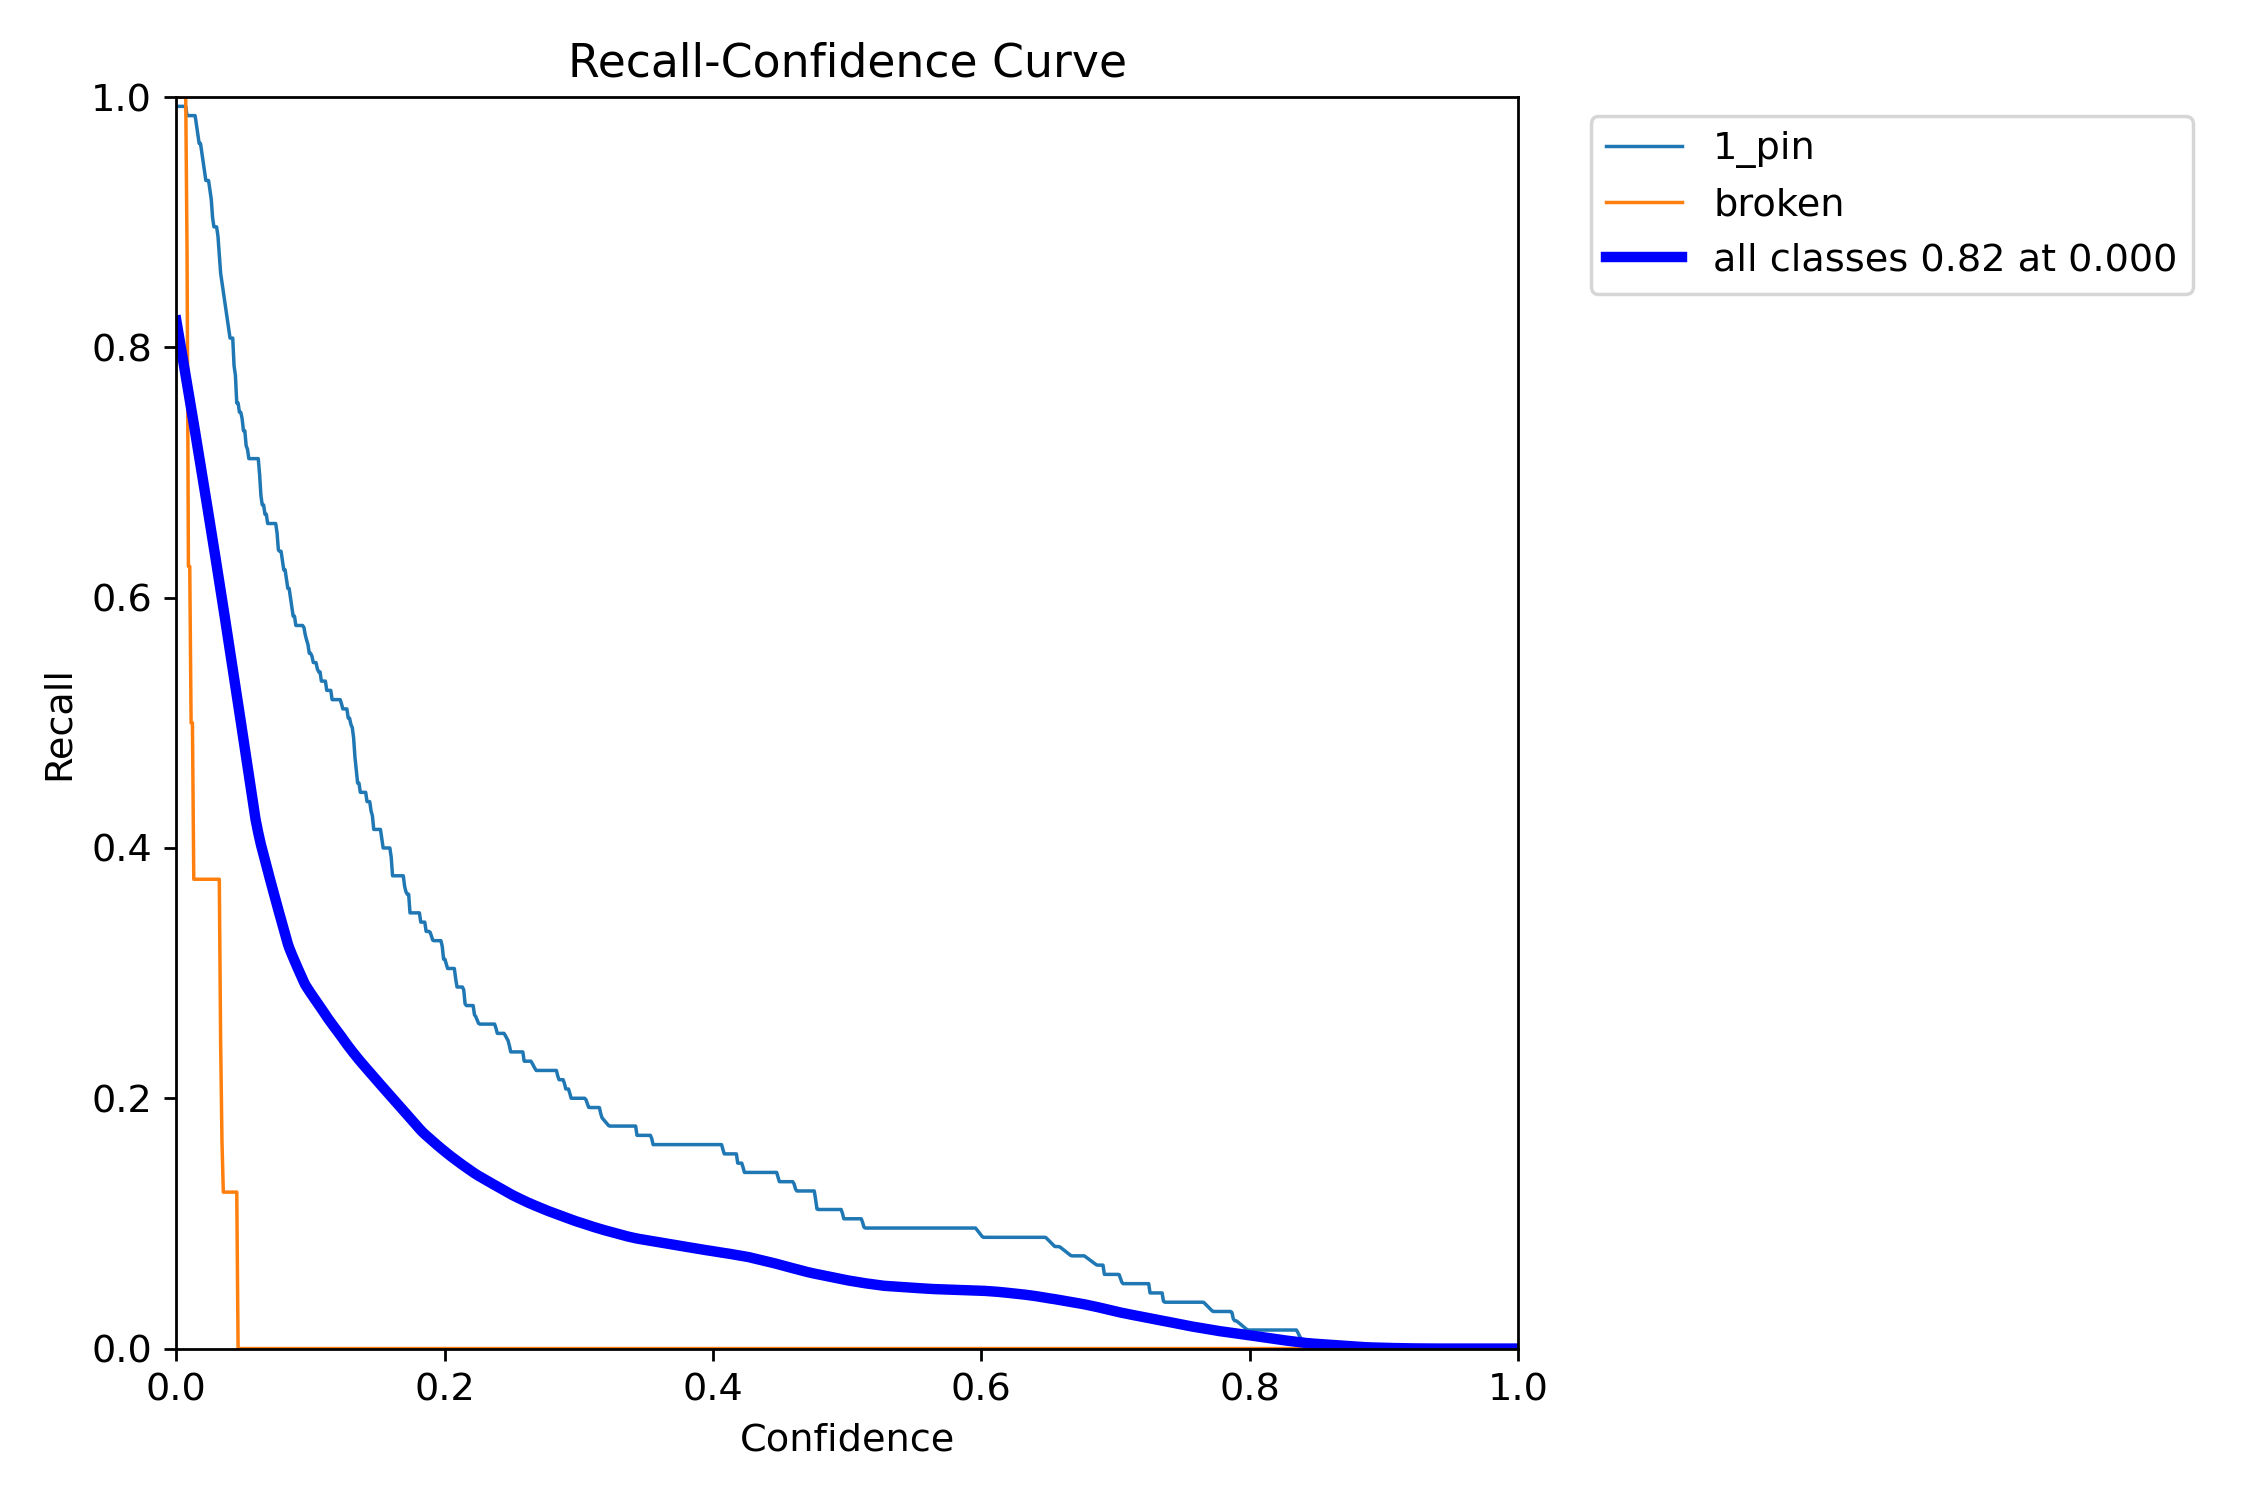

In [ ]:


# Display the Recall curve generated during model evaluation.
# The Recall curve shows how the model's recall changes across
# different confidence thresholds. It indicates the proportion
# of ground truth objects that are successfully detected by the
# model and helps evaluate the detector's ability to minimize
# false negatives.

Image("runs/detect/CV_Pin/YOLOv8n_Tuned/BoxR_curve.png")

# **4.Box Accept/Reject Method**

# Box Accept/Reject Criteria (3 Marks)

The final inspection decision is made based on the object detection results produced by the trained YOLO model.

## Acceptance Criteria

A box is **accepted** only if all of the following conditions are satisfied:

- The box contains **exactly 15 good pins (`1_pin`)**.
- **No defective objects** are detected.

## Rejection Criteria

A box is **rejected** if any of the following conditions are met:

- At least one defective object is detected, including:
  - `front_bend`
  - `broken`
  - `wrong_color`
  - `contamination`
  - `missing_pin`
  - `missing_separator`

- Any bin contains **more than one pin** (duplicate pin detected in a single bin).

- A **separator is missing**.

If any rejection condition is satisfied, the entire box is classified as **REJECT**; otherwise, it is classified as **ACCEPT**.

# **Method to determine if the box is accepted or rejected**

In [ ]:
def accept_reject(results):

    # Count of correctly detected good pins (class 0)
    good_count = 0

    # Count of all defective detections (all classes except 0)
    bad_count = 0

    # Dictionary to store individual defect type counts for analysis
    defect_counts = {
        "2_pin": 0,
        "3_pin": 0,
        "missing_pin": 0,
        "front_bend": 0,
        "broken": 0,
        "wrong_color": 0,
        "contamination": 0,
        "missing_separator": 0
    }

    # Iterate through each prediction result (each image)
    for result in results:

        # Extract predicted class IDs from model output
        classes = result.boxes.cls.cpu().numpy()

        # Process each detected object
        for cls in classes:

            # Convert tensor value to integer class ID
            cls = int(cls)

            # Good pin condition (class 0)
            if cls == 0:
                good_count += 1

            # Any other class is treated as a defect
            else:
                bad_count += 1

                # Track specific defect type
                if cls == 1:
                    defect_counts["2_pin"] += 1
                elif cls == 2:
                    defect_counts["3_pin"] += 1
                elif cls == 3:
                    defect_counts["missing_pin"] += 1
                elif cls == 4:
                    defect_counts["front_bend"] += 1
                elif cls == 5:
                    defect_counts["broken"] += 1
                elif cls == 6:
                    defect_counts["wrong_color"] += 1
                elif cls == 7:
                    defect_counts["contamination"] += 1
                elif cls == 8:
                    defect_counts["missing_separator"] += 1

    # Print summary of detections
    print(f"Good Pins   : {good_count}")
    print(f"Bad Defects : {bad_count}")
    print("Defect Breakdown:", defect_counts)

    # Decision logic for final classification
    # Accept only if exactly 15 good pins are detected
    # and no defects are present
    if good_count == 15 and bad_count == 0:
        decision = "ACCEPT"
    else:
        decision = "REJECT"

    print(f"\nDecision: {decision}")

    return decision

In [ ]:


# Load the best-trained YOLOv8 model (tuned version)
# This model has been trained and fine-tuned on the custom
# CV pin defect dataset using transfer learning.
model = YOLO("runs/detect/CV_Pin/YOLOv8n_Tuned/weights/best.pt")

# Run inference on the unseen test images
# - source: path to test dataset images
# - conf: confidence threshold (filters weak detections)
# - save: saves output images with bounding boxes
# - verbose: disables extra logging output
results = model.predict(
    source=os.path.join(dataset_path, "test", "images"),
    conf=0.10,
    save=True,
    verbose=False
)

# Retrieve class name mapping from the trained model
# Example: {0: '1_pin', 1: '2_pin', ...}
class_names = model.names

# Apply accept/reject logic on predictions
# This function counts good pins and defects and decides
# whether the box should be accepted or rejected.
accept_reject(results)


Results saved to /content/runs/detect/predict-2
Good Pins   : 590
Bad Defects : 0
Defect Breakdown: {'2_pin': 0, '3_pin': 0, 'missing_pin': 0, 'front_bend': 0, 'broken': 0, 'wrong_color': 0, 'contamination': 0, 'missing_separator': 0}

Decision: REJECT


'REJECT'